# Análisis estadístico de `run_benchmark` (más allá de `launch_viz`)

Este notebook carga `results_metadata.parquet` y calcula estadísticas globales y por grupos diagnósticos:
- totales reales de `Wins`, `Regressions`, `High_Uncertainty`, `Edge_Cases` (sin muestreo),
- comparación con los IDs guardados en `focus_groups_ids.json` (muestreados),
- medias/medianas de `oks_base`, `oks_ours`, `delta_oks`, `entropy`, `nll`, `covariance_vol`,
- visualizaciones para entender el comportamiento del modelo.

In [10]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

In [ ]:
# Resolver raíz de proyecto
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
outputs_root = project_root / 'outputs'

# Busca runs con parquet
runs_with_parquet = []
for day in sorted(outputs_root.glob('*')):
    if not day.is_dir():
        continue
    for run in sorted(day.glob('*')):
        pq = run / 'results_metadata.parquet'
        if run.is_dir() and pq.exists():
            runs_with_parquet.append(run)

print(f'Runs con parquet encontrados: {len(runs_with_parquet)}')
for r in runs_with_parquet[-10:]:
    print('-', r.relative_to(project_root))

# Elige run automáticamente (el último con parquet) o asígnalo manualmente
#if runs_with_parquet:
#    run_dir = runs_with_parquet[-1]
#else:
    # Ejemplo manual (ajústalo si no hay detección automática)
run_dir = project_root / 'outputs' / '2026-02-12' / '18-08-52'

print('Run seleccionado:', run_dir.relative_to(project_root) if run_dir.exists() else run_dir)

Runs con parquet encontrados: 21
- outputs\2026-02-09\15-36-33
- outputs\2026-02-09\15-37-09
- outputs\2026-02-09\15-37-18
- outputs\2026-02-09\15-37-53
- outputs\2026-02-11\12-29-48
- outputs\2026-02-11\12-36-26
- outputs\2026-02-11\12-40-42
- outputs\2026-02-12\16-35-10
- outputs\2026-02-12\18-08-52
- outputs\2026-02-13\16-53-57
Run seleccionado: outputs\2026-02-13\16-53-57


In [13]:
# Carga resultados masivos
parquet_path = run_dir / 'results_metadata.parquet'
assert parquet_path.exists(), f'No existe {parquet_path}'

df = pd.read_parquet(parquet_path)
print('Filas:', len(df))
print('Columnas:', list(df.columns))
df.head(3)

Filas: 500
Columnas: ['image_id', 'dataset', 'oks_base', 'oks_ours', 'delta_oks', 'nll', 'entropy', 'covariance_vol', 'n_components']


,image_id,dataset,oks_base,oks_ours,delta_oks,nll,entropy,covariance_vol,n_components
0,532481,coco,0.022157,0.056576,0.034419,0.0,3.671232,2.301026,1
1,458755,coco,0.064065,0.053869,-0.010196,0.0,3.415299,1.781439,1
2,385029,coco,0.001246,0.000010,-0.001236,0.0,4.661301,5.398651,1


In [14]:
# Definiciones diagnósticas (mismas reglas que diagnostics.py)
OKS_IMPROVEMENT_THRESHOLD = 0.1
OKS_FAILURE_THRESHOLD = 0.5
COV_VOL_QUANTILE = 0.90

wins_mask = df['oks_ours'] > (df['oks_base'] + OKS_IMPROVEMENT_THRESHOLD)
reg_mask = df['oks_base'] > (df['oks_ours'] + OKS_IMPROVEMENT_THRESHOLD)

if 'covariance_vol' in df.columns:
    cov_threshold = float(df['covariance_vol'].quantile(COV_VOL_QUANTILE))
    hu_mask = df['covariance_vol'] > cov_threshold
else:
    cov_threshold = np.nan
    hu_mask = pd.Series(False, index=df.index)

ec_mask = (df['oks_base'] < OKS_FAILURE_THRESHOLD) & (df['oks_ours'] < OKS_FAILURE_THRESHOLD)

totals = pd.DataFrame({
    'group': ['Wins', 'Regressions', 'High_Uncertainty', 'Edge_Cases'],
    'count_total_candidates': [int(wins_mask.sum()), int(reg_mask.sum()), int(hu_mask.sum()), int(ec_mask.sum())],
})

totals

,group,count_total_candidates
0,Wins,19
1,Regressions,9
2,High_Uncertainty,50
3,Edge_Cases,500


In [15]:
# Comparar contra focus_groups_ids.json (si existe, suele venir muestreado)
focus_path = run_dir / 'focus_groups_ids.json'
if focus_path.exists():
    with open(focus_path, 'r', encoding='utf-8') as f:
        focus = json.load(f)

    sampled = pd.DataFrame({
        'group': ['Wins', 'Regressions', 'High_Uncertainty', 'Edge_Cases'],
        'count_saved_in_focus_groups_ids': [
            len(focus.get('Wins', [])),
            len(focus.get('Regressions', [])),
            len(focus.get('High_Uncertainty', [])),
            len(focus.get('Edge_Cases', [])),
        ]
    })
    comparison = totals.merge(sampled, on='group', how='left')
else:
    comparison = totals.copy()
    comparison['count_saved_in_focus_groups_ids'] = np.nan

comparison

,group,count_total_candidates,count_saved_in_focus_groups_ids
0,Wins,19,19
1,Regressions,9,9
2,High_Uncertainty,50,47
3,Edge_Cases,500,50


In [16]:
# Estadísticas globales de métricas clave
metric_cols = [c for c in ['oks_base', 'oks_ours', 'delta_oks', 'nll', 'entropy', 'covariance_vol', 'n_components'] if c in df.columns]
stats = df[metric_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats = stats.rename(columns={'50%': 'median'})
stats

,mean,std,min,25%,median,75%,max
oks_base,0.093074,0.085876,0.000000,0.004814,0.078613,0.152396,0.418334
oks_ours,0.100447,0.092465,0.000000,0.008054,0.091674,0.161435,0.462578
delta_oks,0.007373,0.048220,-0.228058,-0.012982,0.000000,0.028730,0.235278
nll,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
entropy,3.537403,0.714814,3.048653,3.148449,3.236462,3.516019,6.808824
covariance_vol,2.327382,3.045055,0.996225,1.362635,1.482204,1.827803,27.443487
n_components,1.022000,0.146830,1.000000,1.000000,1.000000,1.000000,2.000000


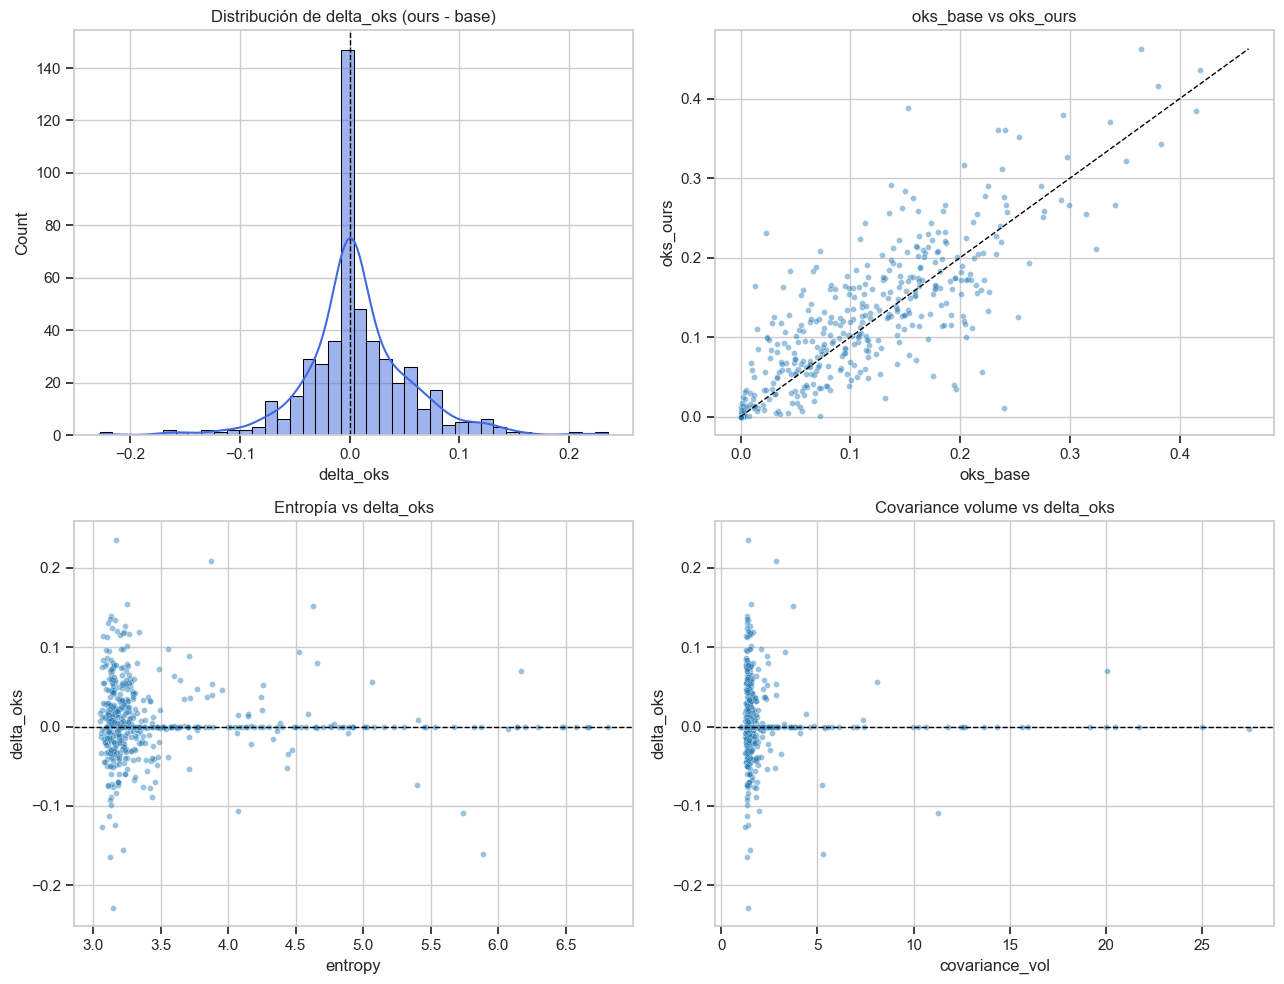

In [18]:
# Visualizaciones útiles para análisis
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1) Histograma delta_oks
if 'delta_oks' in df.columns:
    sns.histplot(df['delta_oks'], bins=40, kde=True, ax=axes[0, 0], color='royalblue')
    axes[0, 0].axvline(0.0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_title('Distribución de delta_oks (ours - base)')

# 2) Scatter oks_base vs oks_ours
if {'oks_base', 'oks_ours'}.issubset(df.columns):
    sns.scatterplot(data=df, x='oks_base', y='oks_ours', s=18, alpha=0.45, ax=axes[0, 1])
    lim_low = min(df['oks_base'].min(), df['oks_ours'].min())
    lim_high = max(df['oks_base'].max(), df['oks_ours'].max())
    axes[0, 1].plot([lim_low, lim_high], [lim_low, lim_high], 'k--', linewidth=1)
    axes[0, 1].set_title('oks_base vs oks_ours')

# 3) Entropía vs delta_oks
if {'entropy', 'delta_oks'}.issubset(df.columns):
    sns.scatterplot(data=df, x='entropy', y='delta_oks', s=18, alpha=0.45, ax=axes[1, 0])
    axes[1, 0].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_title('Entropía vs delta_oks')

# 4) Covariance volume vs delta_oks
if {'covariance_vol', 'delta_oks'}.issubset(df.columns):
    sns.scatterplot(data=df, x='covariance_vol', y='delta_oks', s=18, alpha=0.45, ax=axes[1, 1])
    axes[1, 1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1, 1].set_title('Covariance volume vs delta_oks')

plt.tight_layout()
plt.show()

In [9]:
# Top casos para inspección manual
cols = [c for c in ['image_id', 'dataset', 'oks_base', 'oks_ours', 'delta_oks', 'entropy', 'nll', 'covariance_vol'] if c in df.columns]

print('Top 10 mejoras (delta_oks alto):')
display(df.sort_values('delta_oks', ascending=False)[cols].head(10))

print('Top 10 regresiones (delta_oks bajo):')
display(df.sort_values('delta_oks', ascending=True)[cols].head(10))

Top 10 mejoras (delta_oks alto):


,image_id,dataset,oks_base,oks_ours,delta_oks,entropy,nll,covariance_vol
2209,367195,coco,4.007714e-43,0.356040,0.356040,6.380917,0.0,17.173964
474,533816,coco,1.355252e-01,0.350668,0.215142,3.175924,0.0,1.402206
659,157601,coco,4.910272e-03,0.208498,0.203588,3.695851,0.0,1.337093
976,150417,coco,6.136105e-02,0.255650,0.194289,4.531893,0.0,3.779473
1755,365886,coco,3.025852e-05,0.185035,0.185005,3.151836,0.0,1.368833
1002,420840,coco,8.842781e-02,0.268379,0.179952,3.132401,0.0,1.342487
1383,127270,coco,4.171979e-01,0.595165,0.177967,3.168036,0.0,1.391189
567,271997,coco,1.869074e-02,0.187942,0.169251,3.120181,0.0,1.326182
237,99024,coco,1.295286e-02,0.171278,0.158325,5.706273,0.0,7.726181
1605,201646,coco,2.131091e-02,0.179299,0.157988,5.772146,0.0,8.100891


Top 10 regresiones (delta_oks bajo):


,image_id,dataset,oks_base,oks_ours,delta_oks,entropy,nll,covariance_vol
1102,437514,coco,0.445172,0.069207,-0.375964,4.777752,0.0,2.420093
713,247917,coco,0.388056,0.036466,-0.351590,3.883591,0.0,1.368229
1673,160864,coco,0.452809,0.104245,-0.348564,3.970471,0.0,1.683824
499,345466,coco,0.415128,0.074566,-0.340562,3.356446,0.0,1.679623
738,518326,coco,0.355712,0.028261,-0.327450,5.404500,0.0,7.564972
472,132408,coco,0.336589,0.010254,-0.326335,4.935788,0.0,4.559647
1349,356505,coco,0.323803,0.000282,-0.323521,3.563281,0.0,2.065565
520,17905,coco,0.346508,0.025042,-0.321466,5.060756,0.0,5.431526
1543,512776,coco,0.325867,0.009562,-0.316305,5.724278,0.0,9.337514
2288,457559,coco,0.401964,0.092170,-0.309794,3.942803,0.0,1.476037
